## LOGISTIC REGRESSION ASSIGNMENT


In [10]:
#Load the dataset
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

train_df=pd.read_csv('Titanic_train.csv')
test_df=pd.read_csv('Titanic_test.csv')
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


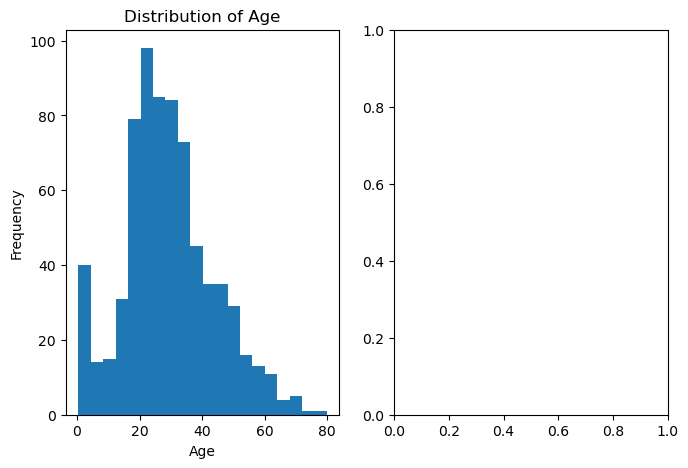

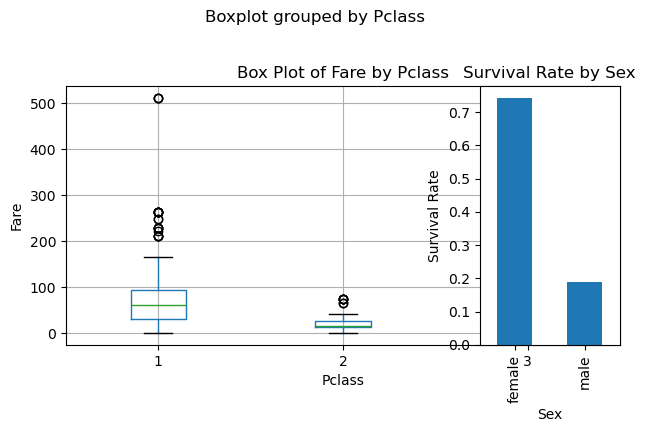

In [11]:
# Visualize some features
plt.figure(figsize=(12, 5))

# Histogram of Age
plt.subplot(1, 3, 1)
plt.hist(train_df["Age"].dropna(), bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")

# Box plot of Fare by Pclass
plt.subplot(1, 3, 2)
train_df.boxplot(column="Fare", by="Pclass")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.title("Box Plot of Fare by Pclass")

# Bar chart of Survived by Sex
plt.subplot(1, 3, 3)
train_df.groupby("Sex")["Survived"].mean().plot(kind="bar")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Sex")

plt.tight_layout()
plt.show()

In [12]:
#data preprocessing
# Fill missing values
train_df["Age"].fillna(train_df["Age"].mean(), inplace=True) # Fill missing values in Age with the mean
train_df["Embarked"].fillna(train_df["Embarked"].mode()[0], inplace=True) # Fill missing values in Embarked with the mode
train_df["Sex"] = train_df["Sex"].map({"male":0, "female":1})

In [13]:
# Create dummy variables
train_df = pd.get_dummies(train_df, columns=["Embarked"], prefix="Embarked")

In [15]:
# Select features for the model
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked_C", "Embarked_Q", "Embarked_S"] # Select features
X = train_df[features] # Features for model
y = train_df["Survived"] # Target variable

In [26]:
# model building
# Split the data into training and test sets
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42) # Split the data
print(x_train.shape, x_val.shape, y_train.shape, y_val.shape)

(712, 9) (179, 9) (712,) (179,)


In [21]:
#initialize the model
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
# Evaluate the model
y_pred = model.predict(x_val) # Predictions on the test set
y_pred_proba = model.predict_proba(x_val)[:, 1] # Predicted probabilities where the passenger survived, here [:, 1] means we are taking the second column of the predicted probabilities because the second column represents the probability of the passenger survived
y_pred_proba

array([0.10743177, 0.2232368 , 0.13621611, 0.88825832, 0.74468675,
       0.93180119, 0.67709677, 0.09190592, 0.76288693, 0.92232157,
       0.33494464, 0.06934551, 0.37397577, 0.14967841, 0.19832264,
       0.93786003, 0.30078857, 0.67714073, 0.24683727, 0.3308892 ,
       0.12215728, 0.41035218, 0.61807288, 0.13660488, 0.10588356,
       0.06909501, 0.46933799, 0.22433922, 0.08217402, 0.5995057 ,
       0.1399262 , 0.66472013, 0.55148265, 0.60904212, 0.14377784,
       0.12763179, 0.46200254, 0.67709677, 0.94226696, 0.10430682,
       0.202855  , 0.08109121, 0.10434339, 0.13540802, 0.57298577,
       0.09191239, 0.14000642, 0.12591916, 0.12192722, 0.33318309,
       0.72356137, 0.80681881, 0.04031774, 0.51768336, 0.04939952,
       0.93345675, 0.21786471, 0.93113449, 0.77715705, 0.74557463,
       0.13253692, 0.86057154, 0.76559154, 0.44282878, 0.13540802,
       0.63064807, 0.3155146 , 0.10636072, 0.14921928, 0.87301519,
       0.75643659, 0.9495527 , 0.57944557, 0.90323714, 0.12553

In [23]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_val, y_pred) # here we are comparing the actual values of y_val with the predicted values of y_pred
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred_proba)

In [24]:
# print evaluation metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}")


Accuracy: 0.8100558659217877
Precision: 0.7857142857142857
Recall: 0.7432432432432432
F1 Score: 0.7638888888888888
ROC AUC: 0.8824967824967825


Confusion Matrix:
[[90 15]
 [19 55]]


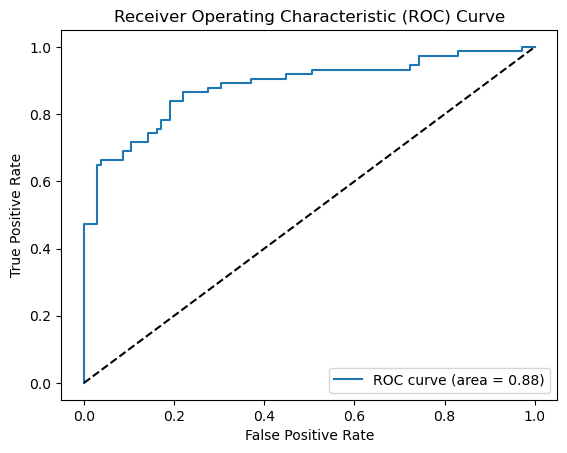

In [28]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

In [29]:
# 5. Interpretation:
#a. Interpret the coefficients of the logistic regression model.
#b. Discuss the significance of features in predicting the target variable (survival probability in this case).

In [30]:
# interpret the coefficients of the logistic regression model
coefficients = model.coef_[0] # Coefficients of the model (Beta values) which are used to calculate the log-odds of the target variable
intercept = model.intercept_[0]
print(f"Intercept: {intercept}")
for feature, coef in zip(features, coefficients):
    print(f"{feature}: {coef}")

Intercept: 1.8264746910683662
Pclass: -0.9374016925455559
Sex: 2.5944266269524525
Age: -0.031251004600712964
SibSp: -0.2970413954389795
Parch: -0.11284430550116452
Fare: 0.002538571939571506
Embarked_C: 0.16779379846095216
Embarked_Q: 0.040218618175107836
Embarked_S: -0.2564476150660653


In [31]:
# b. Discuss the significance of features
print("\nFeature Significance:")
if model.coef_[0][1] > 0:
    print("Sex: Being female significantly increases the chances of survival.")
else:
    print("Sex: Being female significantly decreases the chances of survival.")

if model.coef_[0][0] > 0:
    print("Pclass: Higher Pclass (1st class) is associated with higher survival chances.")
else:
    print("Pclass: Higher Pclass (1st class) is associated with lower survival chances.")


Feature Significance:
Sex: Being female significantly increases the chances of survival.
Pclass: Higher Pclass (1st class) is associated with lower survival chances.
